## load json

In [2]:
import pandas as pd
ds = pd.read_json('test_data/maestro-v1.0.0.json')
ds_2017 = ds[ds['year'] == 2017]

In [17]:
df = ds_2017[['audio_filename', 'split', 'midi_filename']]

In [19]:
# add a column named 'inst_name' and set it to a dict with key 'Acoustic Piano' and value 'Acoustic Piano'
df['inst_names'] = df.apply(lambda row: {'Acoustic Piano': 'Acoustic Piano'}, axis=1)
# change the name 'midi_filename' to 'midi_path'
df.rename(columns={'midi_filename': 'midi_path'}, inplace=True)
df.rename(columns={'audio_filename': 'audio_path'}, inplace=True)

/tmp/ipykernel_788469/2951258111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['inst_names'] = df.apply(lambda row: {'Acoustic Piano': 'Acoustic Piano'}, axis=1)
/tmp/ipykernel_788469/2951258111.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={'midi_filename': 'midi_path'}, inplace=True)
/tmp/ipykernel_788469/2951258111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-

In [20]:
df.to_json('data/maestro-v1.0.0_2017.json', orient='records')

## calculate metrics

In [2]:
import note_seq
import pandas as pd
from contrib import metrics_utils
import mir_eval

In [3]:
df = pd.read_json('data/maestro-v1.0.0_2017.json')
test_list = df[df['split'] == 'test']['midi_path']
test_list = test_list.tolist()

In [6]:
frame_f1 = []
frame_recall = []
frame_precision = []
onset_precision = []
onset_recall = []
onset_f1 = []
onset_offset_precision = []
onset_offset_recall = []
onset_offset_f1 = []

In [7]:
for file_name in test_list:
    midi_name = (file_name.split('/')[1])
    midi_path = 'data/2017/' + midi_name
    raw_ns = note_seq.midi_file_to_note_sequence(midi_path)
    pred_path = 'out/'+ midi_name.split('.')[0] + '.mid'
    pred_ns = note_seq.midi_file_to_note_sequence(pred_path)

    raw_pianoroll = metrics_utils.get_prettymidi_pianoroll(raw_ns,fps = 10,is_drum=False)
    pred_pianoroll = metrics_utils.get_prettymidi_pianoroll(pred_ns,fps = 10,is_drum=False)
    precision, recall, f1 = metrics_utils.frame_metrics(raw_pianoroll, pred_pianoroll, velocity_threshold=0.01)

    frame_f1.append(f1)
    frame_recall.append(recall)
    frame_precision.append(precision)

    est_intervals, est_pitches, est_velocities = (
        note_seq.sequences_lib.sequence_to_valued_intervals(pred_ns))

    ref_intervals, ref_pitches, ref_velocities = (
        note_seq.sequences_lib.sequence_to_valued_intervals(raw_ns))

    precision, recall, f_measure, avg_overlap_ratio = (
    mir_eval.transcription.precision_recall_f1_overlap(
        ref_intervals=ref_intervals,
        ref_pitches=ref_pitches,
        est_intervals=est_intervals,
        est_pitches=est_pitches,
        offset_ratio=None))
    del avg_overlap_ratio

    onset_precision.append(precision)
    onset_recall.append(recall)
    onset_f1.append(f_measure)

In [8]:
print('frame_f1: ', sum(frame_f1)/len(frame_f1))
print('frame_recall: ', sum(frame_recall)/len(frame_recall))
print('frame_precision: ', sum(frame_precision)/len(frame_precision))
print('onset_precision: ', sum(onset_precision)/len(onset_precision))
print('onset_recall: ', sum(onset_recall)/len(onset_recall))
print('onset_f1: ', sum(onset_f1)/len(onset_f1))

frame_f1:  0.6156909505626424
frame_recall:  0.91788112548858
frame_precision:  0.4860689927393159
onset_precision:  0.9926746163935984
onset_recall:  0.9509846043754105
onset_f1:  0.9712033665317973


In [5]:
for file_name in test_list:
    midi_name = (file_name.split('/')[1])
    midi_path = 'data/2017/' + midi_name
    raw_ns = note_seq.midi_file_to_note_sequence(midi_path)
    pred_path = 'out/'+ midi_name.split('.')[0] + '.mid'
    pred_ns = note_seq.midi_file_to_note_sequence(pred_path)

    est_intervals, est_pitches, est_velocities = (
        note_seq.sequences_lib.sequence_to_valued_intervals(pred_ns))

    ref_intervals, ref_pitches, ref_velocities = (
        note_seq.sequences_lib.sequence_to_valued_intervals(raw_ns))

    precision, recall, f_measure, avg_overlap_ratio = (
    mir_eval.transcription.precision_recall_f1_overlap(
        ref_intervals=ref_intervals,
        ref_pitches=ref_pitches,
        est_intervals=est_intervals,
        est_pitches=est_pitches,
        offset_ratio=None))
    del avg_overlap_ratio

    onset_precision.append(precision)
    onset_recall.append(recall)
    onset_f1.append(f_measure)

0.9934719120426043 0.9360634509550017 0.9639136594716226
0.9875877632898696 0.9516733115863235 0.9692979757583216
0.9862955935062196 0.898923904688701 0.940585101035488
0.9905440500765799 0.9390782828282829 0.964124833911268
0.9916666666666667 0.9608695652173913 0.97602523659306
0.992561260210035 0.958855854586445 0.9754174729448862
0.9920983318700615 0.9564113415150233 0.9739280327515623
0.9843106995884774 0.8820004609356995 0.9303512823629514
0.9957627118644068 0.9475806451612904 0.9710743801652894
0.9948320413436692 0.9673366834170855 0.9808917197452229
0.9996571820363387 0.9681274900398407 0.9836397368864901
0.9960179193628671 0.9832923832923833 0.9896142433234422
0.9973333333333333 0.988110964332893 0.9927007299270073
0.9953051643192489 0.9754601226993865 0.9852827265685515


In [10]:
from contrib import summaries
for file_name in test_list:
    midi_name = (file_name.split('/')[1])
    midi_path = 'data/2017/' + midi_name
    raw_ns = note_seq.midi_file_to_note_sequence(midi_path)
    pred_path = 'data/out/'+ midi_name.split('.')[0] + '.mid'
    pred_ns = note_seq.midi_file_to_note_sequence(pred_path)
    a, b = summaries.note_sequence_to_pianoroll_image(pred_ns, raw_ns)
    break

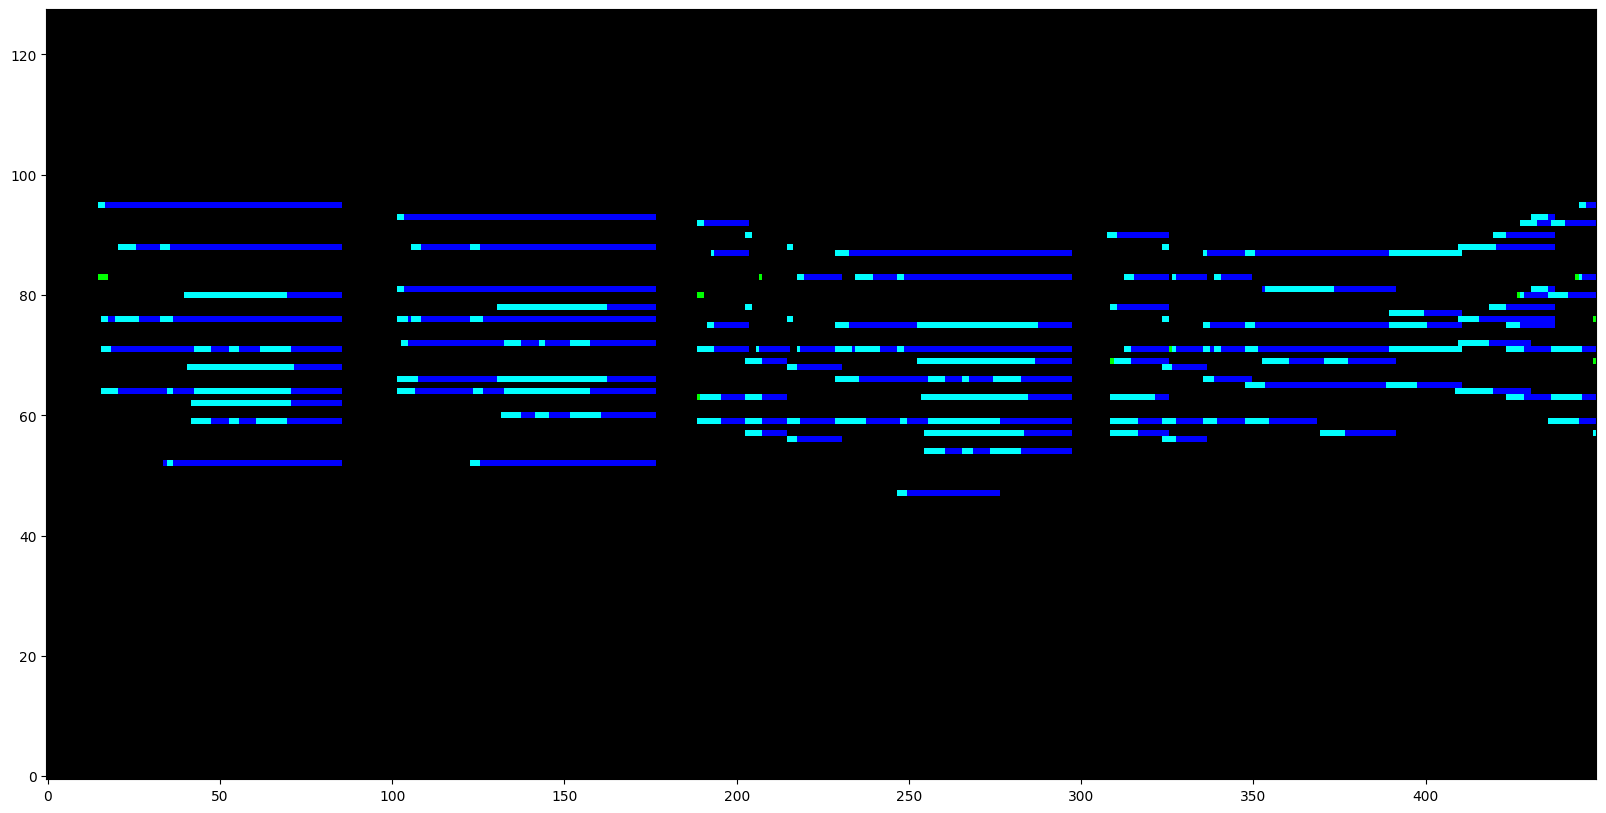

In [13]:
from matplotlib import pyplot as plt
import numpy as np
plt.figure(figsize=(20, 10))
# plt.imshow(np.transpose(a), origin='lower', aspect='auto')
#
plt.imshow(b, origin='lower', aspect='auto')

In [9]:
b[0,0,:]

array([0., 0., 0.])